#Preprocessing Module

#Install libraries

In [ ]:
!pip install imbalanced-learn

# **Load Libraries**

In [ ]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from matplotlib.colors import LogNorm

drive.mount('/content/drive')

Mounted at /content/drive


# Load **Dataset**

In [ ]:
path = '/content/drive/MyDrive/zeek24data'

df = pd.read_csv('/content/drive/MyDrive/zeek24data/zeekdata_combined.csv')
unprocessed_df = df

#Features
for header in unprocessed_df.columns:
    print(f"• {header}")

print(f"Total columns: {len(unprocessed_df.columns)}")

• community_id
• conn_state
• duration
• history
• src_ip_zeek
• src_port_zeek
• dest_ip_zeek
• dest_port_zeek
• local_orig
• local_resp
• missed_bytes
• orig_bytes
• orig_ip_bytes
• orig_pkts
• proto
• resp_bytes
• resp_ip_bytes
• resp_pkts
• service
• ts
• uid
• datetime
• label_tactic
Total columns: 23


#Keep the top 4 instances

In [ ]:
target_classes = [
    'none',
    'Discovery',
    'Credential Access',
    'Reconnaissance'
]

print(f"Filtering dataset to explicitly keep: {target_classes}\n")

# Filter the dataframe to ONLY include rows matching these 4 classes
df = df[df['label_tactic'].isin(target_classes)].copy()

# Reset the index so row numbers remain continuous after dropping the minority classes
df.reset_index(drop=True, inplace=True)

print("--- NEW Class Distribution ---")
print(df['label_tactic'].value_counts())

# Print the new total size of your dataset
print(f"\nNew total rows after filtering: {df.shape[0]}")

output_path = '/content/drive/MyDrive/zeek24data/check_keep_reconnaissance.csv'
df.to_csv(output_path, index=False)

Filtering dataset to explicitly keep: ['none', 'Discovery', 'Credential Access', 'Reconnaissance']

--- NEW Class Distribution ---
label_tactic
none                 138167
Discovery             67585
Credential Access     43495
Reconnaissance        10690
Name: count, dtype: int64

New total rows after filtering: 259937


#Exploratory Data Analysis

descriptive evaluation can be based on the paper (will skip for now) , other eda related shit nagawa na sa excel

paper ng features - https://ieeexplore-ieee-org.dlsu.idm.oclc.org/document/7885840

Desc based on paper:

(1) Complete Network Configuration = complete computer network; number of PCs, server(s), router, and firewall

(2) Complete Traffic = sequence of packets from a source that can be a host, router, or switch to a destination

(3) Labeled Dataset = dataset can be unlabeled, partially-labeled, or fully-labeled

(4) Complete Interaction = having all network interactions such as within or between internal LANs

(5) Complete Capture = complete network capture

(6) Available Protocols =   complete dataset should have both normal and anomalous traffic.

(7) Attack Diversity = have different types of  attacks

(8) Heterogeneity = different sources of dataset creation

(9) Feature Set = usability of features

(10) Metadata = proper documentation

In [ ]:
#use this dataframe -> unprocessed_df
#unprocessed_df.head()

#Identify Data Types
#unprocessed_df.dtypes

null_percentage_per_column = unprocessed_df.isnull().mean() * 100

print("Null percentage per column:\n")

for header, pct in null_percentage_per_column.items():
    print(f"{header} = {pct:.2f}%")


Null percentage per column:

community_id = 0.00%
conn_state = 0.00%
duration = 2.99%
history = 0.06%
src_ip_zeek = 0.00%
src_port_zeek = 0.00%
dest_ip_zeek = 0.00%
dest_port_zeek = 0.00%
local_orig = 0.00%
local_resp = 0.00%
missed_bytes = 0.00%
orig_bytes = 2.99%
orig_ip_bytes = 0.00%
orig_pkts = 0.00%
proto = 0.00%
resp_bytes = 2.99%
resp_ip_bytes = 0.00%
resp_pkts = 0.00%
service = 8.05%
ts = 0.00%
uid = 0.00%
datetime = 0.00%
label_tactic = 0.00%
label_technique = 0.00%
label_binary = 0.00%
label_cve = 0.00%


In [ ]:
print("Unique values per column:\n")


for col in unprocessed_df.columns:
    unique_count = unprocessed_df[col].nunique(dropna=True)
    print(f"{col} = {unique_count} unique values")



Unique values per column:

community_id = 80885 unique values
conn_state = 6 unique values
duration = 48522 unique values
history = 57 unique values
src_ip_zeek = 91 unique values
src_port_zeek = 34795 unique values
dest_ip_zeek = 230 unique values
dest_port_zeek = 23 unique values
local_orig = 2 unique values
local_resp = 2 unique values
missed_bytes = 13 unique values
orig_bytes = 299 unique values
orig_ip_bytes = 711 unique values
orig_pkts = 72 unique values
proto = 3 unique values
resp_bytes = 153 unique values
resp_ip_bytes = 251 unique values
resp_pkts = 68 unique values
service = 18 unique values
ts = 94786 unique values
uid = 95182 unique values
datetime = 94785 unique values
label_tactic = 8 unique values
label_technique = 7 unique values
label_binary = 4 unique values
label_cve = 2 unique values


Individual value counts:

proto
tcp     51265
udp     44545
icmp       61
Name: count, dtype: int64


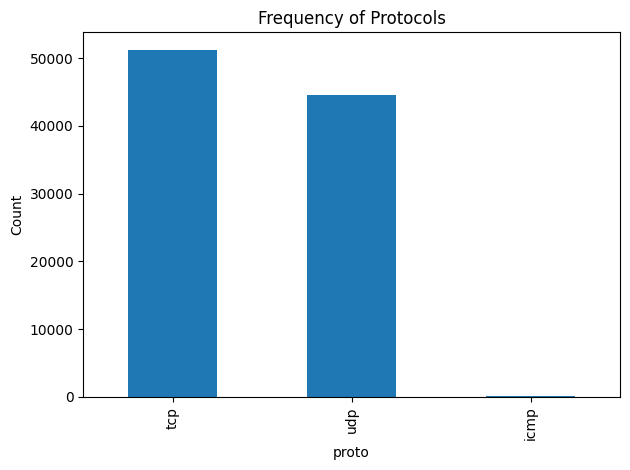

In [ ]:
column_name = 'proto'
value_counts = unprocessed_df[column_name].value_counts()

print("Individual value counts:\n")
print(value_counts)

plt.figure()
value_counts.plot(kind='bar')
plt.xlabel(column_name)
plt.ylabel('Count')
plt.title(f'Frequency of Protocols')
plt.tight_layout()
plt.show()

Individual value counts:

service
dns        44072
ssl        42951
http         509
ntp          330
gssapi       257
smb          204
ntlm         204
dce_rpc      102
dhcp          29
ftp            2
Name: count, dtype: int64


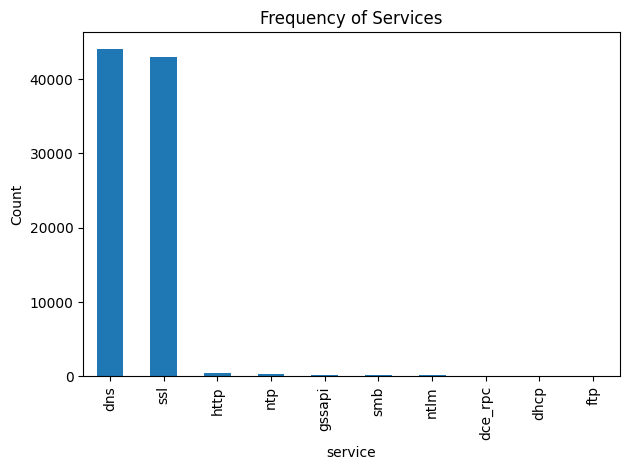

In [ ]:
column_name = 'service'

split_values = (
    unprocessed_df[column_name]
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)

value_counts = split_values.value_counts()

print("Individual value counts:\n")
print(value_counts)

plt.figure()
value_counts.plot(kind='bar')
plt.xlabel(column_name)
plt.ylabel('Count')
plt.title(f'Frequency of Services')
plt.tight_layout()
plt.show()


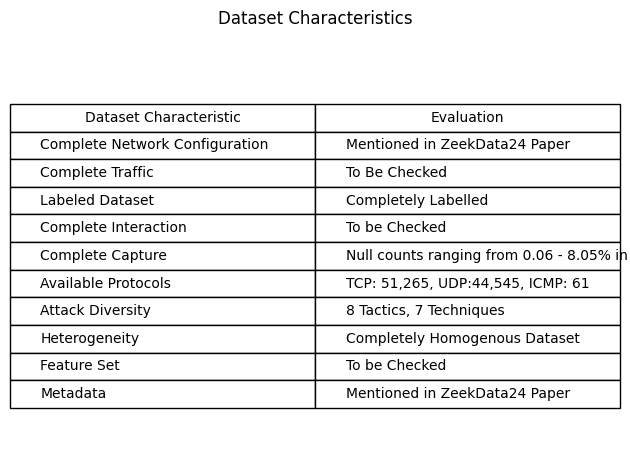

In [ ]:
columns = ["Dataset Characteristic" , "Evaluation", ]

rows = [
    ["Complete Network Configuration","Mentioned in ZeekData24 Paper",],
    ["Complete Traffic","To Be Checked",],
    ["Labeled Dataset","Completely Labelled",],
    ["Complete Interaction","To be Checked",],
    ["Complete Capture","Null counts ranging from 0.06 - 8.05% in 5 Columns",],
    ["Available Protocols","TCP: 51,265, UDP:44,545, ICMP: 61",],
    ["Attack Diversity","8 Tactics, 7 Techniques",],
    ["Heterogeneity","Completely Homogenous Dataset",],
    ["Feature Set","To be Checked",],
    ["Metadata","Mentioned in ZeekData24 Paper",],
]

fig, ax = plt.subplots()
ax.axis('off')

table = ax.table(
    cellText=rows,
    colLabels=columns,
    loc='center',
    cellLoc='left'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title("Dataset Characteristics", pad=20)
plt.tight_layout()
plt.show()

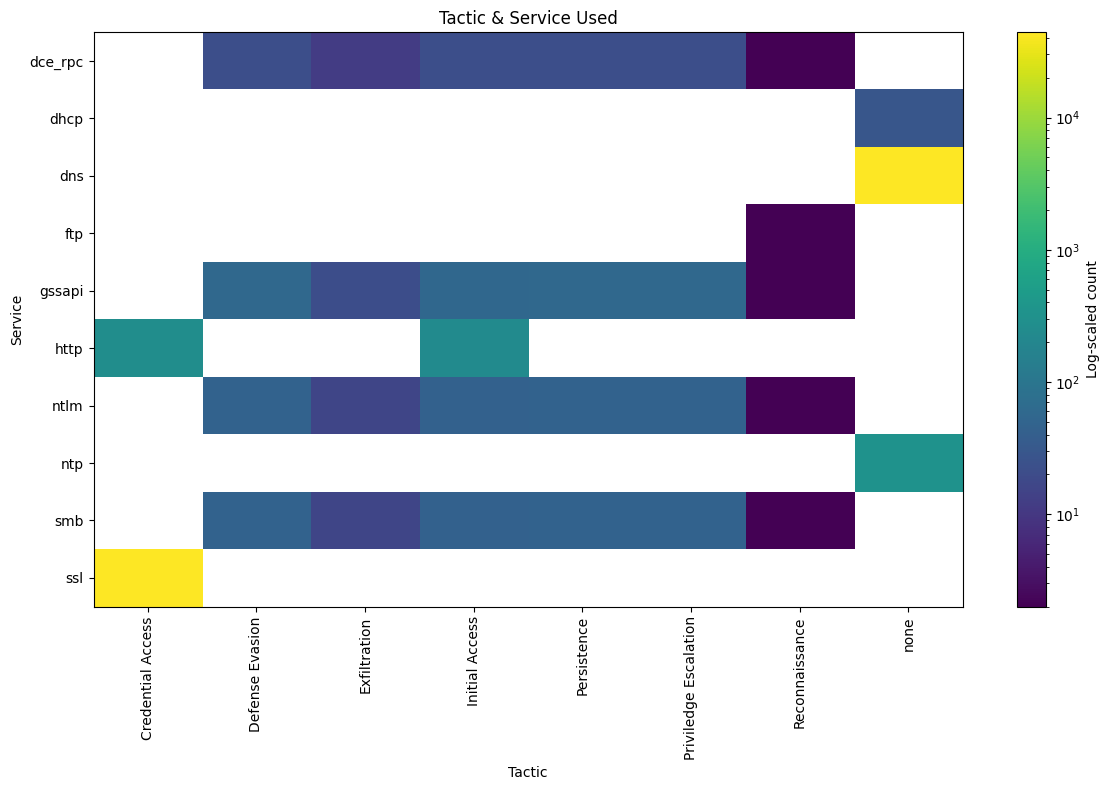

In [ ]:

service_col = "service"
tactic_col = "label_tactic"


services_exploded = (
    unprocessed_df[[service_col, tactic_col]]
    .dropna()
    .assign(service=lambda x: x[service_col].str.split(','))
    .explode(service_col)
)

services_exploded[service_col] = services_exploded[service_col].str.strip()


co_occurrence = pd.crosstab(
    services_exploded[service_col],
    services_exploded[tactic_col]
)


plt.figure(figsize=(12, 8))
plt.imshow(co_occurrence, aspect='auto', norm=LogNorm())
plt.colorbar(label="Log-scaled count")

plt.xticks(range(len(co_occurrence.columns)), co_occurrence.columns, rotation=90)
plt.yticks(range(len(co_occurrence.index)), co_occurrence.index)

plt.xlabel("Tactic")
plt.ylabel("Service")
plt.title("Tactic & Service Used")

plt.tight_layout()
plt.show()

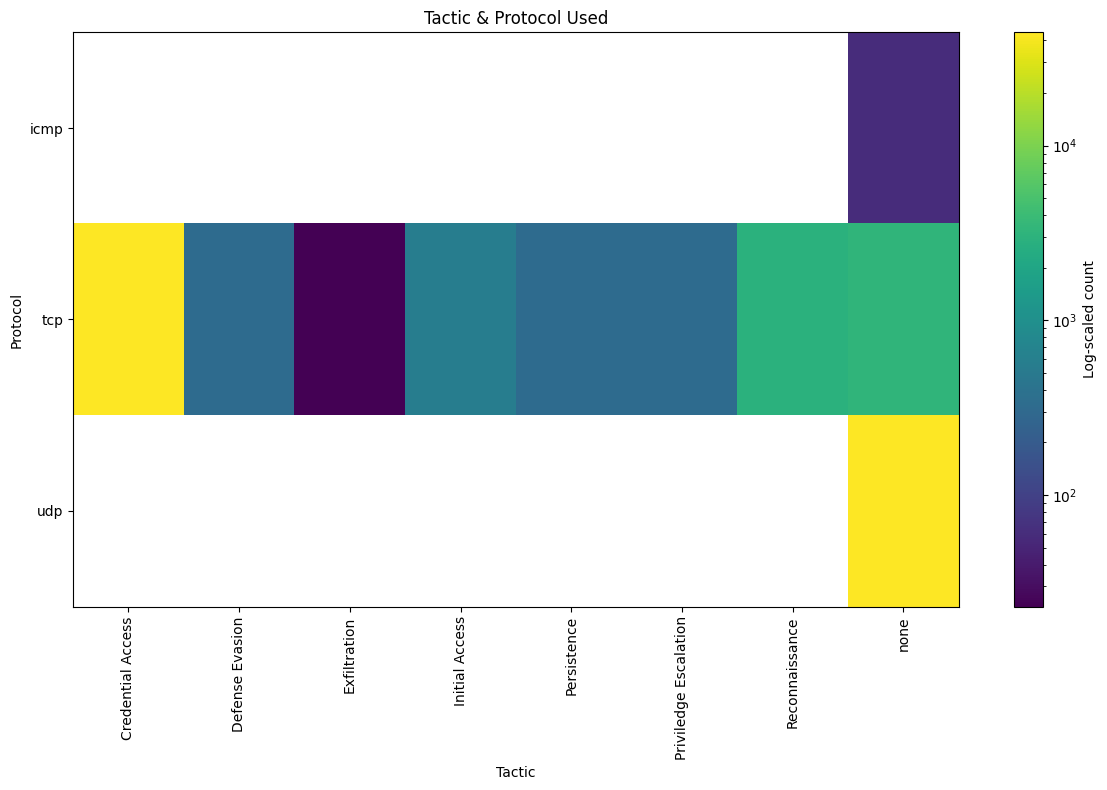

In [ ]:
service_col = "proto"
tactic_col = "label_tactic"


services_exploded = (
    unprocessed_df[[service_col, tactic_col]]
    .dropna()
    .assign(service=lambda x: x[service_col].str.split(','))
    .explode(service_col)
)

services_exploded[service_col] = services_exploded[service_col].str.strip()


co_occurrence = pd.crosstab(
    services_exploded[service_col],
    services_exploded[tactic_col]
)


plt.figure(figsize=(12, 8))
plt.imshow(co_occurrence, aspect='auto', norm=LogNorm())
plt.colorbar(label="Log-scaled count")

plt.xticks(range(len(co_occurrence.columns)), co_occurrence.columns, rotation=90)
plt.yticks(range(len(co_occurrence.index)), co_occurrence.index)

plt.xlabel("Tactic")
plt.ylabel("Protocol")
plt.title("Tactic & Protocol Used")

plt.tight_layout()
plt.show()

#Remove Irrelevant Features



*   community_id
*   datetime
* ts
* uid
* src_ip_zeek
* dest_ip_zeek




In [ ]:
df = df.drop(columns=[
    "community_id",
    "datetime",
    "ts",
    "uid",
    "src_ip_zeek",
    "dest_ip_zeek"
])

for header in df.columns:
    print(f"• {header}")

print(f"Total columns: {len(df.columns)}")

output_path = '/content/drive/MyDrive/zeek24data/check_remove_irrelevant.csv'
df.to_csv(output_path)

• conn_state
• duration
• history
• src_port_zeek
• dest_port_zeek
• local_orig
• local_resp
• missed_bytes
• orig_bytes
• orig_ip_bytes
• orig_pkts
• proto
• resp_bytes
• resp_ip_bytes
• resp_pkts
• service
• label_tactic
Total columns: 17


#Data Cleaning

In [ ]:
#Check for missing values

null_percentage_per_column = df.isnull().mean() * 100

print("Before:")
print("Null percentage per column:\n")
for header, pct in null_percentage_per_column.items():
    print(f"{header} = {pct:.2f}%")



Before:
Null percentage per column:

conn_state = 0.00%
duration = 25.87%
history = 0.25%
src_port_zeek = 0.00%
dest_port_zeek = 0.00%
local_orig = 0.00%
local_resp = 0.00%
missed_bytes = 0.00%
orig_bytes = 25.87%
orig_ip_bytes = 0.00%
orig_pkts = 0.00%
proto = 0.00%
resp_bytes = 25.87%
resp_ip_bytes = 0.00%
resp_pkts = 0.00%
service = 33.24%
label_tactic = 0.00%


In [ ]:
#Handling of Missing values

#Replace blank entries in the service feature to unknown
df['service'] = df['service'].replace('', 'unknown').fillna('unknown')
df['service'].unique()

#drop missing values for duration, orig_bytes, resp_bytes, history
df = df.dropna(subset=["history"])

null_percentage_per_column = df.isnull().mean() * 100

print("After:")
print("Null percentage per column:\n")

for header, pct in null_percentage_per_column.items():
    print(f"{header} = {pct:.2f}%")

#Remove Duplicates
if df.duplicated().any():
    dup_count = df.duplicated().sum()
    df = df.drop_duplicates()
    print(f"\nRemoved {dup_count} duplicate rows.")

output_path = '/content/drive/MyDrive/zeek24data/check_data_cleaning.csv'
df.to_csv(output_path)

After:
Null percentage per column:

conn_state = 0.00%
duration = 25.79%
history = 0.00%
src_port_zeek = 0.00%
dest_port_zeek = 0.00%
local_orig = 0.00%
local_resp = 0.00%
missed_bytes = 0.00%
orig_bytes = 25.79%
orig_ip_bytes = 0.00%
orig_pkts = 0.00%
proto = 0.00%
resp_bytes = 25.79%
resp_ip_bytes = 0.00%
resp_pkts = 0.00%
service = 0.00%
label_tactic = 0.00%

Removed 1444 duplicate rows.


#Binning of Port Numbers

In [ ]:
#src_port_zeek and dest_port_zeek binning
def port_binning(port):
    if pd.isna(port):
        return 4
    elif 0 <= port <= 1023:
        return 1
    elif port <= 49151:
        return 2
    elif port <= 65535:
        return 3
    else:
        return 4


df['src_port_bin'] = df['src_port_zeek'].apply(port_binning)
df['dest_port_bin'] = df['dest_port_zeek'].apply(port_binning)

output_path = '/content/drive/MyDrive/zeek24data/check_binning_of_ports.csv'
df.to_csv(output_path)

#Binning of Continuous Values
*   duration
*   missed_bytes
* orig_bytes
* orig_ip_bytes
* orig_pkts
* resp_bytes
* resp_ip_bytes
* resp_pkts



In [ ]:
# Continuous values binning with MNAR Post-Binning Isolation
def mean_std_binning(df, feature):
    df[feature] = pd.to_numeric(df[feature], errors='coerce')

    # Drop NaNs only for the mathematical calculation
    values = df[feature].dropna()

    #Check if the column is entirely empty, just return 0s
    if len(values) == 0:
        df[f"{feature}_bin"] = 0
        return df

    min_val = values.min()
    mean_val = values.mean()
    stddev_val = values.std()

    if min_val >= 0:
        while mean_val - 2 * stddev_val < 0:
            mean_val += stddev_val

    # Define bin edges
    edges = [
        -np.inf,
        mean_val - 2 * stddev_val,
        mean_val - stddev_val,
        mean_val,
        mean_val + stddev_val,
        mean_val + 2 * stddev_val,
        np.inf
    ]

    binned_col = f"{feature}_bin"

    # Assign bins 1–6.
    # Valid numbers go to bins 1-6. Missing values naturally become 'NaN'
    df[binned_col] = pd.cut(
        df[feature],
        bins=edges,
        labels=[1, 2, 3, 4, 5, 6]
    )

    # Check if there are any missing values in this newly binned column
    if df[binned_col].isna().any():
        # Add '0' as an officially recognized category for our missing values
        df[binned_col] = df[binned_col].cat.add_categories([0])
        # Fill the NaNs with the '0' bin
        df[binned_col] = df[binned_col].fillna(0)

    # Convert to nullable integer type now that everything is safely numbered 0-6
    df[binned_col] = df[binned_col].astype("Int64")

    return df

# List of continuous features
continuous_features = [
    "duration",
    "missed_bytes",
    "orig_bytes",
    "orig_ip_bytes",
    "orig_pkts",
    "resp_bytes",
    "resp_ip_bytes",
    "resp_pkts"
]

# Apply the binning function to all continuous features
print("Starting continuous binning and MNAR isolation...")
for feature in continuous_features:
    # Check if feature exists to avoid KeyError
    if feature in df.columns:
        df = mean_std_binning(df, feature)
        print(f"Successfully binned: {feature} -> {feature}_bin")

print("\n--- Current Columns in Dataset ---")
for header in df.columns:
    print(f"• {header}")

print("\n--- Manual Inspection (First 15 Rows) ---")
# Adjust the columns below depending on what you want to look at
inspection_cols = ['duration', 'duration_bin', 'orig_bytes', 'orig_bytes_bin']
available_cols = [col for col in inspection_cols if col in df.columns]
if available_cols:
    print(df[available_cols].head(15))

# Export to CSV
output_path = '/content/drive/MyDrive/zeek24data/check_binning_of_continuous.csv'
print(f"\nExporting finalized dataset to: {output_path}")

df.to_csv(output_path, index=False)
print("Export complete!")

Starting continuous binning and MNAR isolation...
Successfully binned: duration -> duration_bin
Successfully binned: missed_bytes -> missed_bytes_bin
Successfully binned: orig_bytes -> orig_bytes_bin
Successfully binned: orig_ip_bytes -> orig_ip_bytes_bin
Successfully binned: orig_pkts -> orig_pkts_bin
Successfully binned: resp_bytes -> resp_bytes_bin
Successfully binned: resp_ip_bytes -> resp_ip_bytes_bin
Successfully binned: resp_pkts -> resp_pkts_bin

--- Current Columns in Dataset ---
• conn_state
• duration
• history
• src_port_zeek
• dest_port_zeek
• local_orig
• local_resp
• missed_bytes
• orig_bytes
• orig_ip_bytes
• orig_pkts
• proto
• resp_bytes
• resp_ip_bytes
• resp_pkts
• service
• label_tactic
• src_port_bin
• dest_port_bin
• duration_bin
• missed_bytes_bin
• orig_bytes_bin
• orig_ip_bytes_bin
• orig_pkts_bin
• resp_bytes_bin
• resp_ip_bytes_bin
• resp_pkts_bin

--- Manual Inspection (First 15 Rows) ---
    duration  duration_bin  orig_bytes  orig_bytes_bin
0   0.001853  

#Boolean Encoding
* local_orig
* local_resp

In [ ]:

df['local_orig'] = df['local_orig'].astype(int)
df['local_resp'] = df['local_resp'].astype(int)

print(df['local_orig'].unique())
print(df['local_resp'].unique())


"""
print(df.head(15))
"""
output_path = '/content/drive/MyDrive/zeek24data/check_boolean_encoding.csv'
df.to_csv(output_path)

[0 1]
[0 1]


#One Hot-Encoding of Port Bins
* src_port_bin
* dest_port_bin

In [ ]:
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False) #init onehotencoder

to_bin = ["src_port_bin", "dest_port_bin"]

enc.fit(df[to_bin])

encoded_array = enc.transform(df[to_bin])
feature_names = enc.get_feature_names_out(to_bin)

encoded_df = pd.DataFrame(
    encoded_array,
    columns=feature_names,
    index=df.index
)

# Add encoded columns to original df
df = pd.concat([df, encoded_df], axis=1)

output_path = '/content/drive/MyDrive/zeek24data/check_onehot_ports.csv'
df.to_csv(output_path)

print(f"First 10 one-hot columns: {df.columns[:10].tolist()}")

df.head(10)


First 10 one-hot columns: ['conn_state', 'duration', 'history', 'src_port_zeek', 'dest_port_zeek', 'local_orig', 'local_resp', 'missed_bytes', 'orig_bytes', 'orig_ip_bytes']


,conn_state,duration,history,src_port_zeek,dest_port_zeek,local_orig,local_resp,missed_bytes,orig_bytes,orig_ip_bytes,...,orig_pkts_bin,resp_bytes_bin,resp_ip_bytes_bin,resp_pkts_bin,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3
0,SF,0.001853,Dd,33222,53,0,0,0,192.0,304,...,1,1,1,1,0.0,1.0,0.0,1.0,0.0,0.0
1,SF,0.000822,Dd,53091,53,0,0,0,192.0,304,...,1,1,1,1,0.0,0.0,1.0,1.0,0.0,0.0
2,SF,0.001532,Dd,44981,53,0,0,0,192.0,304,...,1,1,1,1,0.0,1.0,0.0,1.0,0.0,0.0
3,SF,0.001031,Dd,44978,53,0,0,0,152.0,264,...,1,1,1,1,0.0,1.0,0.0,1.0,0.0,0.0
4,SF,0.000708,Dd,59152,53,0,0,0,192.0,304,...,1,1,1,1,0.0,0.0,1.0,1.0,0.0,0.0
6,SF,0.000592,Dd,57753,53,0,0,0,152.0,264,...,1,1,1,1,0.0,0.0,1.0,1.0,0.0,0.0
7,SF,0.001456,Dd,47313,53,0,0,0,152.0,264,...,1,1,1,1,0.0,1.0,0.0,1.0,0.0,0.0
8,S0,8.048920,D,64391,53,0,0,0,215.0,355,...,1,1,1,1,0.0,0.0,1.0,1.0,0.0,0.0
9,SF,0.000687,Dd,41421,53,0,0,0,192.0,304,...,1,1,1,1,0.0,1.0,0.0,1.0,0.0,0.0
10,S0,0.000018,D,55122,53,0,0,0,96.0,152,...,1,1,1,1,0.0,0.0,1.0,1.0,0.0,0.0


#One Hot-Encoding of Continuous Features Bin
*   duration
*   missed_bytes
* orig_bytes
* orig_ip_bytes
* orig_pkts
* resp_bytes
* resp_ip_bytes
* resp_pkts


In [ ]:
"""
print("duration bin unique:" , df['duration_bin'].unique())
print("missed_bytes bin unique:" , df['missed_bytes_bin'].unique())
print("orig_bytes bin unique: ", df['orig_bytes_bin'].unique())
print("orig_ip_bytes bin unique: ", df['orig_ip_bytes_bin'].unique())
print("orig_pkts bin unique: ", df['orig_pkts_bin'].unique())
print("resp_bytes bin unique: ", df['resp_bytes_bin'].unique())
print("resp_ip_bytes bin unique: ", df['resp_ip_bytes_bin'].unique())
print("resp_pkts bin unique: ", df['resp_pkts_bin'].unique())
"""

bin_columns = [
    'duration_bin',
    'missed_bytes_bin',
    'orig_bytes_bin',
    'orig_ip_bytes_bin',
    'orig_pkts_bin',
    'resp_bytes_bin',
    'resp_ip_bytes_bin',
    'resp_pkts_bin'
]



from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# List of bin columns
bin_columns = [
    'duration_bin',
    'missed_bytes_bin',
    'orig_bytes_bin',
    'orig_ip_bytes_bin',
    'orig_pkts_bin',
    'resp_bytes_bin',
    'resp_ip_bytes_bin',
    'resp_pkts_bin'
]


encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(df[bin_columns])
feature_names = encoder.get_feature_names_out(bin_columns)

encoded_df = pd.DataFrame(
    encoded_array,
    columns=feature_names,
    index=df.index
)

# Add encoded columns to original df
df = pd.concat([df, encoded_df], axis=1)

output_path = '/content/drive/MyDrive/zeek24data/check_onehot_continuous.csv'
df.to_csv(output_path)

print(f"First 10 one-hot columns: {df.columns[:10].tolist()}")

df.head(10)




First 10 one-hot columns: ['conn_state', 'duration', 'history', 'src_port_zeek', 'dest_port_zeek', 'local_orig', 'local_resp', 'missed_bytes', 'orig_bytes', 'orig_ip_bytes']


,conn_state,duration,history,src_port_zeek,dest_port_zeek,local_orig,local_resp,missed_bytes,orig_bytes,orig_ip_bytes,...,resp_ip_bytes_bin_3.0,resp_ip_bytes_bin_4.0,resp_ip_bytes_bin_5.0,resp_ip_bytes_bin_6.0,resp_pkts_bin_1.0,resp_pkts_bin_2.0,resp_pkts_bin_3.0,resp_pkts_bin_4.0,resp_pkts_bin_5.0,resp_pkts_bin_6.0
0,SF,0.001853,Dd,33222,53,0,0,0,192.0,304,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,SF,0.000822,Dd,53091,53,0,0,0,192.0,304,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,SF,0.001532,Dd,44981,53,0,0,0,192.0,304,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,SF,0.001031,Dd,44978,53,0,0,0,152.0,264,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,SF,0.000708,Dd,59152,53,0,0,0,192.0,304,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,SF,0.000592,Dd,57753,53,0,0,0,152.0,264,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,SF,0.001456,Dd,47313,53,0,0,0,152.0,264,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
8,S0,8.048920,D,64391,53,0,0,0,215.0,355,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9,SF,0.000687,Dd,41421,53,0,0,0,192.0,304,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10,S0,0.000018,D,55122,53,0,0,0,96.0,152,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


#One-Hot Encoding for Categorical Features

# To be one-hot encoded:
*   conn_state / Connection state (SF, S0, OTH, REJ, RSTO, RSTR)
*   proto / Protocol (tcp, udp, icmp)
* history
* service (dce_rcp, dhcp, dns, ftp, gssapi, http, krb_tcp, ntp, ssh,ssl, unknown)





In [ ]:


enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False) #init onehotencoder

to_bin = ["conn_state", "proto", "history"]

enc.fit(df[to_bin])

encoded_array = enc.transform(df[to_bin])
feature_names = enc.get_feature_names_out(to_bin)

encoded_df = pd.DataFrame(
    encoded_array,
    columns=feature_names,
    index=df.index
)

# Add encoded columns to original df
df = pd.concat([df, encoded_df], axis=1)

#For service feature
service_bins = [
    "dce_rpc",
    "dhcp",
    "dns",
    "ftp",
    "gssapi",
    "http",
    "krb_tcp",
    "ntp",
    "ssh",
    "ssl",
    "unknown"
]

for s in service_bins:
    df[f"service_{s}"] = 0


for idx, value in df["service"].items():
    services = [s.strip() for s in value.split(",")]
    matched = False

    for s in services:
        if s in service_bins:
            df.at[idx, f"service_{s}"] = 1
            matched = True

    if not matched:
        df.at[idx, "service_unknown"] = 1


output_path = '/content/drive/MyDrive/zeek24data/check_onehot_categorical.csv'
df.to_csv(output_path)

print(f"First 10 one-hot columns: {df.columns[:10].tolist()}")

df.head(15)


First 10 one-hot columns: ['conn_state', 'duration', 'history', 'src_port_zeek', 'dest_port_zeek', 'local_orig', 'local_resp', 'missed_bytes', 'orig_bytes', 'orig_ip_bytes']


,conn_state,duration,history,src_port_zeek,dest_port_zeek,local_orig,local_resp,missed_bytes,orig_bytes,orig_ip_bytes,...,service_dhcp,service_dns,service_ftp,service_gssapi,service_http,service_krb_tcp,service_ntp,service_ssh,service_ssl,service_unknown
0,SF,0.001853,Dd,33222,53,0,0,0,192.0,304,...,0,1,0,0,0,0,0,0,0,0
1,SF,0.000822,Dd,53091,53,0,0,0,192.0,304,...,0,1,0,0,0,0,0,0,0,0
2,SF,0.001532,Dd,44981,53,0,0,0,192.0,304,...,0,1,0,0,0,0,0,0,0,0
3,SF,0.001031,Dd,44978,53,0,0,0,152.0,264,...,0,1,0,0,0,0,0,0,0,0
4,SF,0.000708,Dd,59152,53,0,0,0,192.0,304,...,0,1,0,0,0,0,0,0,0,0
6,SF,0.000592,Dd,57753,53,0,0,0,152.0,264,...,0,1,0,0,0,0,0,0,0,0
7,SF,0.001456,Dd,47313,53,0,0,0,152.0,264,...,0,1,0,0,0,0,0,0,0,0
8,S0,8.048920,D,64391,53,0,0,0,215.0,355,...,0,1,0,0,0,0,0,0,0,0
9,SF,0.000687,Dd,41421,53,0,0,0,192.0,304,...,0,1,0,0,0,0,0,0,0,0
10,S0,0.000018,D,55122,53,0,0,0,96.0,152,...,0,1,0,0,0,0,0,0,0,0


#Drop Original Columns

In [ ]:
print(df.columns)

df = df.drop(columns=[
    'conn_state', 'duration' , 'history' , 'src_port_zeek', 'dest_port_zeek', 'missed_bytes', 'orig_bytes',
    'orig_ip_bytes', 'orig_pkts', 'proto', 'resp_bytes' , 'resp_ip_bytes', 'resp_pkts', 'service',
    'src_port_bin', 'dest_port_bin', 'duration_bin', 'missed_bytes_bin', 'orig_bytes_bin', 'orig_ip_bytes_bin', 'orig_pkts_bin',
    'resp_bytes_bin', 'resp_ip_bytes_bin', 'resp_pkts_bin'
])

print(f"Total columns: {len(df.columns)}")
output_path = '/content/drive/MyDrive/zeek24data/check_drop_original.csv'
df.to_csv(output_path)


Index(['conn_state', 'duration', 'history', 'src_port_zeek', 'dest_port_zeek',
       'local_orig', 'local_resp', 'missed_bytes', 'orig_bytes',
       'orig_ip_bytes',
       ...
       'service_dhcp', 'service_dns', 'service_ftp', 'service_gssapi',
       'service_http', 'service_krb_tcp', 'service_ntp', 'service_ssh',
       'service_ssl', 'service_unknown'],
      dtype='object', length=210)
Total columns: 186


#Information Gain Assesment

In [ ]:
ig_df = df

X = ig_df.drop(columns=["label_tactic"])
y = ig_df["label_tactic"]

ig_scores = mutual_info_classif(
    X,
    y,
    discrete_features="auto",  # handles bins + one-hot correctly
    random_state=42
)

ig_df = pd.DataFrame({
    "feature": X.columns,
    "information_gain": ig_scores
})


zero_ig_features = ig_df[
    ig_df["information_gain"] == 0
]["feature"].tolist()

print("Features with 0 Information Gain:")
print(zero_ig_features)


df = df.drop(columns=zero_ig_features)

print(f"\nDropped {len(zero_ig_features)} features.")
print(f"Remaining features: {df.shape[1]}")

ig_df.head(10)

output_path = '/content/drive/MyDrive/zeek24data/check_drop_zero_infogain.csv'
df.to_csv(output_path)

output_path = '/content/drive/MyDrive/zeek24data/infogain_MC.csv'
ig_df.to_csv(output_path)



Features with 0 Information Gain:
['local_orig', 'missed_bytes_bin_3.0', 'orig_ip_bytes_bin_6.0', 'orig_pkts_bin_6.0', 'resp_bytes_bin_6.0', 'resp_ip_bytes_bin_6.0', 'resp_pkts_bin_5.0', 'conn_state_RSTR', 'conn_state_S1', 'history_Ar', 'history_Hs^ADTdttTaFf', 'history_Hs^ADTdttTatFf', 'history_SADhaFf', 'history_SADhfFa', 'history_SAhDTdttFaf', 'history_SAhDTdttgFaf', 'history_SAhDadfGF', 'history_SAhDar', 'history_SAhDfFa', 'history_ShADTaFf', 'history_ShADTadttTFf', 'history_ShADTdttFTaf', 'history_ShADTdttFafR', 'history_ShADTdttFagf', 'history_ShADTdttTaFR', 'history_ShADTdttTaR', 'history_ShADTdttaFR', 'history_ShADTdttaFf', 'history_ShADTdttaGfF', 'history_ShADTdttaTtFf', 'history_ShADaFf', 'history_ShADaFr', 'history_ShADadFr', 'history_ShADadfFr', 'history_ShADar', 'history_ShADdfrF', 'history_ShADdgR', 'history_ShADfFa', 'history_ShADgdFaf', 'history_ShAFaf', 'history_ShAR', 'history_ShAdfFa', 'history_ShGR', 'history_^dD', 'history_^r', 'history_r', 'service_gssapi', 'servi

#Test-Train Split

In [ ]:
unique_label = df['label_tactic'].value_counts()
print(unique_label)

label_tactic
none                 137015
Discovery             67152
Credential Access     43495
Reconnaissance        10183
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=y)

train_path = '/content/drive/MyDrive/zeek24data/train.csv'
train_df.to_csv(train_path)

#train_df's data is imbalanced for actual training, it will be sent to under/oversampling section.

test_path = '/content/drive/MyDrive/zeek24data/test.csv'
test_df.to_csv(test_path)

unique_label = train_df['label_tactic'].value_counts()
print(unique_label)

label_tactic
none                 109612
Discovery             53722
Credential Access     34796
Reconnaissance         8146
Name: count, dtype: int64


In [ ]:
unique_label = test_df['label_tactic'].value_counts()
print(unique_label)

label_tactic
none                 27403
Discovery            13430
Credential Access     8699
Reconnaissance        2037
Name: count, dtype: int64


#Sampling (RUS - 50% of majority class, SMOTEN - upsample all minority class by 10% of majority class count)
* Random Undersampling for Credential Access and Benign
* SMOTE for Reconnaissance, Initial Access, Priviledge Escalation, Persistence, Defense Evasion, Exfiltration

In [ ]:
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTEN

print("Original distribution:")
print(train_df["label_tactic"].value_counts())

X = train_df.drop(columns=["label_tactic"])
y = train_df["label_tactic"]

# 50% undersampling for majority ("none")
counts = y.value_counts()
target_none = int(counts.get("none", 0) * 0.5)

rus = RandomUnderSampler(
    sampling_strategy={
        "none": target_none
    },
    random_state=42
)

X_rus, y_rus = rus.fit_resample(X, y)

print("\nAfter 50% undersampling:")
print(y_rus.value_counts())


# Oversampling step (10% for minorities, +2k explicitly for Reconnaissance)
current_counts = y_rus.value_counts()
majority_size = current_counts.max()
target_minority = int(majority_size * 0.10)

smote_strategy = {}

for cls, count in current_counts.items():
    clean_cls = str(cls).strip()

    if clean_cls == "none":
        continue

    elif clean_cls == "Reconnaissance":
        #Add  2000 instances to whatever its current count is
        smote_strategy[cls] = count + 2000

    else:
        # Standard 10% rule for all other minority classes
        if count < target_minority:
            smote_strategy[cls] = target_minority

# Check if there's anything to oversample before running SMOTEN
if smote_strategy:
    smote = SMOTEN(
        sampling_strategy=smote_strategy,
        random_state=42
    )
    X_final, y_final = smote.fit_resample(X_rus, y_rus)
else:
    X_final, y_final = X_rus.copy(), y_rus.copy()

print("\nFinal distribution after SMOTEN:")
print(y_final.value_counts())

train_df_balanced = pd.DataFrame(X_final, columns=X.columns)
train_df_balanced["label_tactic"] = y_final

Original distribution:
label_tactic
none                 109612
Discovery             53722
Credential Access     34796
Reconnaissance         8146
Name: count, dtype: int64

After 50% undersampling:
label_tactic
none                 54806
Discovery            53722
Credential Access    34796
Reconnaissance        8146
Name: count, dtype: int64

Final distribution after SMOTEN:
label_tactic
none                 54806
Discovery            53722
Credential Access    34796
Reconnaissance       10146
Name: count, dtype: int64


/tmp/ipykernel_1583/2654220537.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df_balanced["label_tactic"] = y_final


In [ ]:
counts = y_final.value_counts()
print(counts)

label_tactic
none                 54806
Discovery            53722
Credential Access    34796
Reconnaissance       10146
Name: count, dtype: int64


In [ ]:
train_df_balanced = X_final.copy()
train_df_balanced["label_tactic"] = y_final.values

# sanity checks
print("Final shape:", train_df_balanced.shape)
print("\nFinal class distribution:")
print(train_df_balanced["label_tactic"].value_counts())

output_path = '/content/drive/MyDrive/zeek24data/final_train.csv'
train_df_balanced.to_csv(output_path)


Final shape: (153470, 137)

Final class distribution:
label_tactic
none                 54806
Discovery            53722
Credential Access    34796
Reconnaissance       10146
Name: count, dtype: int64


#Sampling (15k All)
* Random Undersampling for Credential Access and Benign
* SMOTE for Reconnaissance, Initial Access, Priviledge Escalation, Persistence, Defense Evasion, Exfiltration

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTEN

print("Original distribution:")
print(train_df["label_tactic"].value_counts())

X = train_df.drop(columns=["label_tactic"])
y = train_df["label_tactic"]

TARGET_CA = 15000

rus = RandomUnderSampler(
    sampling_strategy={"Credential Access": TARGET_CA,
                       "none": TARGET_CA
                       },
    random_state=42
)

X_rus, y_rus = rus.fit_resample(X, y)

print("\nAfter undersampling Credential Access:")
print(y_rus.value_counts())

smote_strategy = {
    cls: TARGET_CA
    for cls, count in y_rus.value_counts().items()
    if cls != "Credential Access" and count < TARGET_CA
}

smote = SMOTEN(
    sampling_strategy=smote_strategy,
    random_state=42
)

X_final, y_final = smote.fit_resample(X_rus, y_rus)

X_final, y_final = smote.fit_resample(X_rus, y_rus)

print("\nFinal distribution after SMOTEN:")
print(y_final.value_counts())

train_df_balanced = X_final.copy()
train_df_balanced["label_tactic"] = y_final
